# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [2]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [4]:
torch.__version__

'2.6.0+cu126'

In [5]:
torch.cuda.is_available()

True

## Loading labels

In [5]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png
...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png


### DataLoader

In [60]:
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.img_labels = data
        self.img_labels['fullpath'] = DATA_PATH+"DRR_images/"+self.img_labels['DRR filename']+".png"
        self.img_dir = DATA_PATH+"DRR_images"
        self.transform = None
        self.target_transform = None
    
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        image = read_image(self.img_labels.iloc[idx]["fullpath"])
        image = image.type(torch.FloatTensor)
        label = self.img_labels.iloc[idx]["score"]
        return image, label
    
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(CustomImageDataset(train), batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(CustomImageDataset(val), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


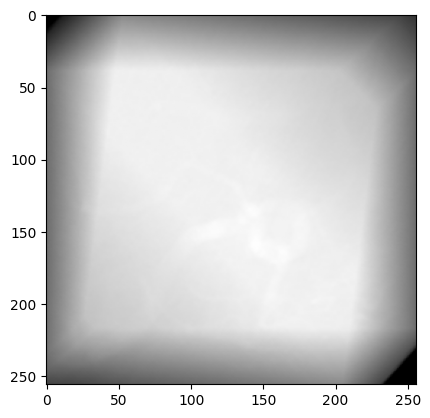

Label: 10.75295815295815


In [61]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [95]:
import torch.nn.functional as F
class Block(nn.Module):
    def __init__(self):
        super(Block, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, 3, 1, 1)  # In: (1, 256, 256), Out: (32, 256, 256)
        self.pool1 = nn.MaxPool2d(2,2)         # In: (32, 256, 256), Out: (32, 64, 64)
        self.conv2 = nn.Conv2d(4, 16, 3, 1, 1) # In: (32, 64, 64), Out: (64, 62, 62)
        self.pool2 = nn.MaxPool2d(2,2)         # In: (64, 62, 62), Out: (64, 15, 15)
        self.flatten = nn.Flatten()
        self.ln1 = nn.Linear(16*64*64, 128)  # Aangepast naar de juiste grootte van de tensor
        self.relu = nn.ReLU()
        self.ln2 = nn.Linear(128,1)


    def forward(self, x):
        x = self.conv1(x)  # Convolution layer 1
        x = self.pool1(x)  # Pooling layer 1
        x = self.conv2(x)  # Convolution layer 2
        x = self.pool2(x)  # Pooling layer 2
        x = self.flatten(x)  # Flatten the tensor
        x = self.ln1(x)  # Fully connected layer
        x = self.relu(x)
        x = self.ln2(x)
        return x


In [96]:
device = torch.device("cuda")
model = Block().to(device)

summary(model, torch.Size([1,256,256]), 64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [64, 4, 256, 256]              40
         MaxPool2d-2          [64, 4, 128, 128]               0
            Conv2d-3         [64, 16, 128, 128]             592
         MaxPool2d-4           [64, 16, 64, 64]               0
           Flatten-5                [64, 65536]               0
            Linear-6                  [64, 128]       8,388,736
              ReLU-7                  [64, 128]               0
            Linear-8                    [64, 1]             129
Total params: 8,389,497
Trainable params: 8,389,497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 16.00
Forward/backward pass size (MB): 352.13
Params size (MB): 32.00
Estimated Total Size (MB): 400.13
----------------------------------------------------------------


In [97]:
output = model(train.to(device))
output

tensor([[ 7.7762],
        [10.4348],
        [ 6.6741],
        [ 7.3708],
        [ 9.9654],
        [ 7.5532],
        [ 9.5275],
        [10.4796],
        [ 8.5006],
        [ 8.8247],
        [12.5306],
        [11.5839],
        [15.5829],
        [ 9.4585],
        [11.6479],
        [ 9.7811],
        [11.4112],
        [16.5809],
        [ 7.4045],
        [ 9.2277],
        [10.5831],
        [12.0979],
        [14.1320],
        [11.1857],
        [ 7.8510],
        [10.5242],
        [10.7987],
        [10.7298],
        [ 9.7630],
        [ 6.2152],
        [10.2131],
        [11.6556],
        [ 4.4632],
        [ 8.6955],
        [11.6990],
        [10.3945],
        [17.4684],
        [11.4568],
        [11.4970],
        [ 9.8223],
        [ 7.3887],
        [17.5421],
        [ 7.6641],
        [10.8485],
        [17.4824],
        [ 7.8895],
        [11.0742],
        [11.6635],
        [16.1548],
        [10.1639],
        [11.7046],
        [ 8.5308],
        [12.

### Loss function

In [98]:
loss_fn = nn.MSELoss()
loss_fn.to(device=device)

MSELoss()

### Optimizer

In [99]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


### Training

In [100]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device).float())
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            running_loss = 0.

    return last_loss

In [101]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 10

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device).float())
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))


    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1
model.train(False)

EPOCH 1:
LOSS train 0.0 valid 1203.390380859375
EPOCH 2:
LOSS train 0.0 valid 1195.150634765625
EPOCH 3:
LOSS train 0.0 valid 1192.840087890625
EPOCH 4:
LOSS train 0.0 valid 1199.9869384765625
EPOCH 5:
LOSS train 0.0 valid 1187.9520263671875
EPOCH 6:
LOSS train 0.0 valid 1189.3802490234375
EPOCH 7:
LOSS train 0.0 valid 1212.7490234375
EPOCH 8:
LOSS train 0.0 valid 1204.3182373046875
EPOCH 9:
LOSS train 0.0 valid 1188.1875
EPOCH 10:
LOSS train 0.0 valid 1188.32275390625


Block(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (ln1): Linear(in_features=65536, out_features=128, bias=True)
  (relu): ReLU()
  (ln2): Linear(in_features=128, out_features=1, bias=True)
)

In [102]:
torch.save(model.state_dict(), "mymodel.pth")

In [103]:
torch.cuda.empty_cache()
del model
del loss_fn

print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())

1703959552
2394947584


In [104]:
device2 = torch.device("cuda")
mymodel = Block()
mymodel.load_state_dict(torch.load("mymodel.pth", weights_only=True))
mymodel.eval()
mymodel.to(device2)

Block(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (ln1): Linear(in_features=65536, out_features=128, bias=True)
  (relu): ReLU()
  (ln2): Linear(in_features=128, out_features=1, bias=True)
)

In [110]:
test, label = next(iter(val_dataloader))


In [13]:
print(test.size())

torch.Size([64, 1, 256, 256])


In [111]:

with torch.no_grad():
    estimate = mymodel(test.to(device2)).detach().cpu().numpy()


In [112]:
estimate[5][0]

np.float32(0.06974734)

[Text(0.5, 1.0, 'ML Performance'),
 Text(0.5, 0, 'Real'),
 Text(0, 0.5, 'Estimated')]

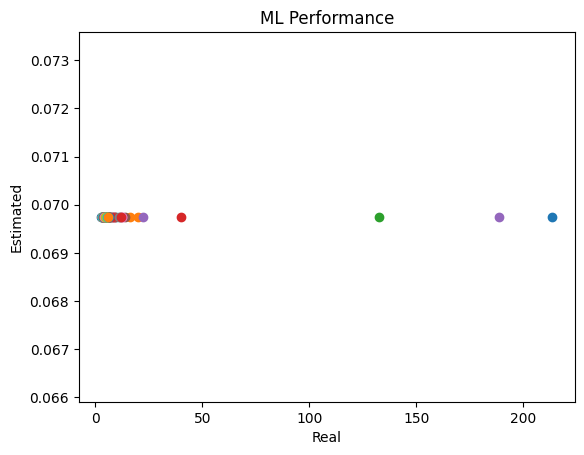

In [113]:

result = []
for i,l in enumerate(label):
    plt.scatter(float(l), float(estimate[i][0]))
    result.append((float(l), float(estimate[i][0])))

plt.gca().update(dict(title='ML Performance', xlabel="Real", ylabel="Estimated"))



    

In [114]:
result

[(3.002080506558118, 0.06974734365940094),
 (5.287749754339994, 0.06974734365940094),
 (6.328142787445113, 0.06974734365940094),
 (2.90133779264214, 0.06974734365940094),
 (188.6363636363636, 0.06974734365940094),
 (3.472727272727273, 0.06974734365940094),
 (8.366795366795367, 0.06974734365940094),
 (3.379285714285714, 0.06974734365940094),
 (5.253475935828877, 0.06974734365940094),
 (6.524014778325123, 0.06974734365940094),
 (2.852380952380952, 0.06974734365940094),
 (19.73697270471464, 0.06974734365940094),
 (3.181534189517529, 0.06974734365940094),
 (8.943880019351717, 0.06974734365940094),
 (3.306713989943804, 0.06974734365940094),
 (5.902632886239443, 0.06974734365940094),
 (3.301474130455728, 0.06974734365940094),
 (5.660919540229886, 0.06974734365940094),
 (5.537574501166105, 0.06974734365940094),
 (9.829629629629629, 0.06974734365940094),
 (4.126845965770171, 0.06974734365940094),
 (16.13793103448276, 0.06974734365940094),
 (4.043478260869565, 0.06974734365940094),
 (9.13699788